# 参考文献
Ising formulations of many NP problems  
Andrew Lucas  
https://arxiv.org/abs/1302.5843

# Maxcut
Maxcut問題とは、一筆書きでできるだけ多くの辺を横切ることができるかを考える問題です。

## ハミルトニアン
Maxcutのハミルトニアンは

$$H = -\sum_{i,j}\frac{1}{2}(1-z_iz_j)$$

zは各頂点の値に対応して1または-1の値を取ります。

## 例
16個の点と25本の辺からなるグラフの問題を解いてみましょう。まず、グラフを描画します。

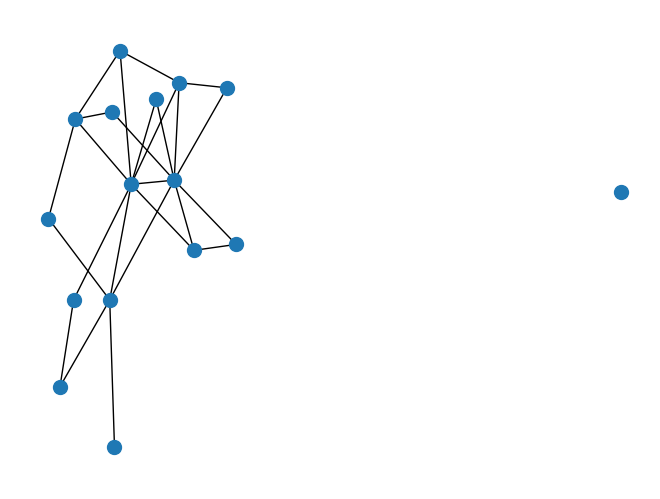

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# Reduced from the original 70 nodes / 130 edges: the new blueqat SDK's QAOA/Vqe
# optimizes against an exact statevector rather than a classical annealer, so a
# 70-qubit problem is computationally infeasible (it would need a 2^70-dimensional
# state). 16 nodes keeps the demo runnable in a few seconds while still showing
# a non-trivial cut.
n = 16
m = 25
seed = 14

options = {'node_size': 100}

G = nx.gnm_random_graph(n, m, seed = seed)
nx.draw(G, **options)

## シミュレータで解く
ここでは、QAOAを用いてシミュレータ上でこの問題を解きます。

/Users/yuichirominato/blueqatSDK/.claude/worktrees/determined-mahavira-bf713e/blueqat/utils.py:399: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:823.)
  total_matrix = torch.sparse_coo_tensor(torch.empty((2, 0), dtype=torch.int64, device=device), torch.empty(0, dtype=torch.complex128, device=device), (dim, dim))


sample:1000110011111000


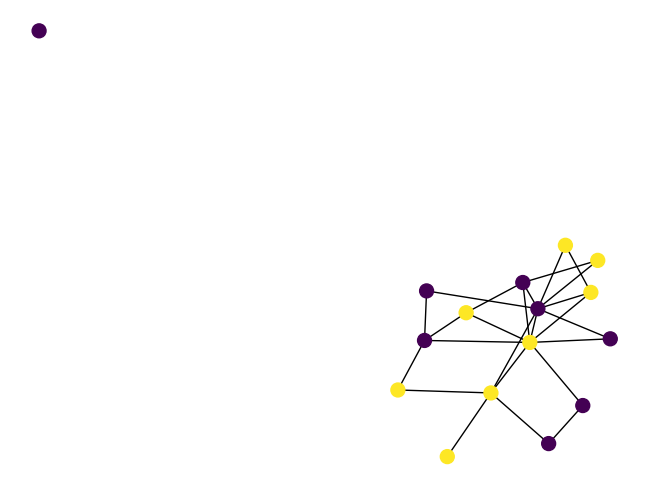

In [2]:
from blueqat.utils import Z, Vqe, QaoaAnsatz
import numpy as np
import time

hamiltonian = sum(Z[e[0]]*Z[e[1]] for e in G.edges)
step = 1

ansatz = QaoaAnsatz(hamiltonian, step)
result = Vqe(ansatz).run(max_iter=100)
b = result.circuit.run(shots=10)
sample = b.most_common(1)[0][0]

print("sample:"+ str(sample))

nx.draw(G, **options, node_color=[int(s) for s in list(sample)])

異なる色の頂点間の辺が、カットされる辺になります。

# Exact Cover

集合$U = \{1,....,n\}$が与えられ、さらにいくつかの部分集合$V_i \in U \{1,....,n\}$が与えられているとします。これらの部分集合からなる集合族の中に、互いに素な部分集合からなり、それらの和集合が$U$と一致するような部分集合族が存在するかどうかを問う問題です。

## QUBO

与えられた部分集合$V_i$が選ばれている場合に$1$、そうでない場合に$0$となる二値変数$q_i$を用意します。部分集合同士が互いに素であり、集合$U$の各要素がちょうど1つの部分集合に属するという条件を考慮すると、この問題のハミルトニアンは次のように定義されます。
$$ H = \sum_{\alpha=1}^{n} ( 1 - \sum_{i:\alpha\in V_i} q_i)^2$$

## シミュレータで解く
ここでは、QAOAを用いてシミュレータ上でこの問題を解きます。

In [3]:
import numpy as np
from blueqat.utils import qubo_bit as q, Vqe, QaoaAnsatz

U = np.array([1, 2, 3])
V_size = 3

V = np.array([[1,2],[1],[3]],dtype=object)

hamiltonian = 0.0
temp = 0.0
for i in range(U.size):
    for j in range(V.size):
        if((np.where(V[j] == U[i]))[0].size > 0):
            temp+= q(j)
    # Note: the new SDK's Expr no longer supports **2 directly, so square via
    # an explicit self-product instead.
    term = 1 - temp
    hamiltonian += term * term
    temp = 0.0

In [4]:
step = 1

ansatz = QaoaAnsatz(hamiltonian, step)
result = Vqe(ansatz).run()
b = result.circuit.run(shots=10)
sample = b.most_common(1)[0][0]
print(sample)

101


# グラフ彩色問題(Graph Coloring)

頂点集合$V$と辺集合$E$からなる無向グラフ$G=(V,E)$が与えられているとします。$n$色が与えられたとき、隣接する2つの頂点が同じ色を持たないようにグラフを彩色できるかを考えます。これは、グラフを彩色するために何色必要かというNP困難問題を一般化したものであり、NP完全問題です。

## QUBO

$n$は頂点の数、$m$は色の数です。
頂点と色の組み合わせを表す行列の各要素に対して二値変数$x_{v,i}$を用意します。したがって、使用する量子ビットの総数は$n*m$になります。

主な制約は2つあります。
1. 各頂点はちょうど1色で表される必要があります。

$$ H_A = \sum_{v} (1 - \sum_{i=1}^{m} q_{v,i})^2 $$

2. 隣接する頂点は異なる色を持つ必要があります。

$$ H_B = \sum_{(uv) \in E}^{n} \sum_{i=1}^{m} q_{u,i}*q_{v,i} $$

## シミュレータで解く
ここでは、QAOAを用いてシミュレータ上でこの問題を解きます。

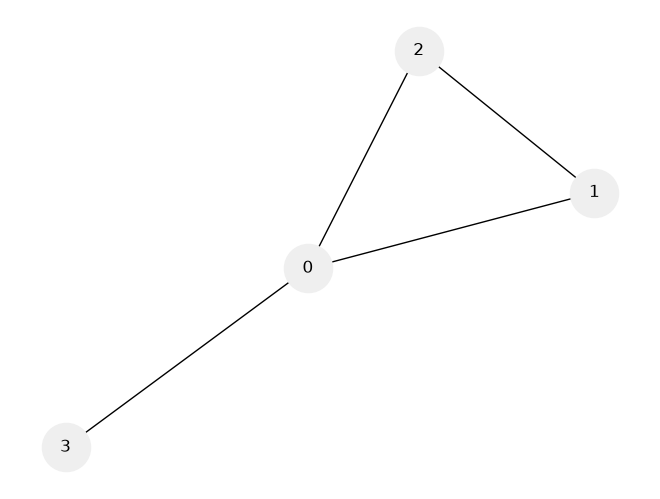

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

options = {'node_color': '#efefef','node_size': 1200,'with_labels':'True'}

n = 4 #number of nodes
m = 3 #number of colors

G = nx.Graph()
G.add_nodes_from(nx.path_graph(n))
G.add_edges_from([(0,1), (0,2), (0,3),(1,2)])
nx.draw(G, **options)

In [6]:
from blueqat.utils import qubo_bit as q, Vqe, QaoaAnsatz
import numpy as np

#make an adjacent matrix
a = nx.to_numpy_array(G)
b = np.zeros((n,m), dtype=int)

my_dict = {}

num = 0
for v in range(n):
    for i in range(m):
        b[v][i] = num
        my_dict[num]=[str(v),i]
        num+=1

h_1= 0.0
const_h = 0.0
for v in range (n):
    for i in range(m):
        const_h = const_h + q(b[v,i])
        
    # Note: the new SDK's Expr no longer supports **2 directly, so square via
    # an explicit self-product instead.
    term = 1 - const_h
    h_1 = h_1 + term * term
    const_h = 0.0
        
h_2 = 0.0    
for u in range(n):
    for v in range(n):
        for i in range(m):
            if(a[u,v]==1):
                h_2 = h_2 + q(b[u,i])*q(b[v,i])
                
h = h_1 + h_2

In [7]:
step = 1

ansatz = QaoaAnsatz(h, step)
result = Vqe(ansatz).run()
b = result.circuit.run(shots=10)

In [8]:
from blueqat import Circuit

arr = []

for samples in list(b):
    circ1 = Circuit(12)
    for i, x in enumerate(list(samples)):
        if x == '1':
            circ1.x[i]
    res = circ1.run(hamiltonian=h)
    arr.append([samples, res])
    print(samples, res)

000010000000 tensor(3., dtype=torch.float64)


001101010000 tensor(4., dtype=torch.float64)


000000010000 tensor(3., dtype=torch.float64)


011000110000 tensor(6., dtype=torch.float64)


100010000010 tensor(1., dtype=torch.float64)


100001000000 tensor(2., dtype=torch.float64)


110001000001 tensor(2., dtype=torch.float64)


010010000000 tensor(4., dtype=torch.float64)


010001000000 tensor(2., dtype=torch.float64)


In [9]:
for item in arr:
    if item[1] == 0.0:
        for i in range(n*m):
            if list(item[0])[i] == "1":
                print(my_dict[i])
        print()